<a href="https://colab.research.google.com/github/Dentriciche/Project_SP/blob/main/03%20-%20Model%20Building/transformer_distilbert_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DistilBERT Fine-tuning for South Park Character Classification

This notebook fine-tunes a pre-trained DistilBERT model for predicting which South Park character spoke a given line of dialogue.

## Why DistilBERT?

DistilBERT is a distilled version of BERT that offers an excellent balance between performance and efficiency:

- **40% faster** than BERT-base
- **40% smaller** (66M parameters vs 110M)
- **97% of BERT's performance** on downstream tasks
- **Pre-trained on massive corpus** - Understands language nuances
- **Transfer learning** - Leverages knowledge from billions of tokens

### Comparison with Custom Transformer:

| Feature | Custom BERT-style | DistilBERT (Pre-trained) |
|---------|------------------|-------------------------|
| Parameters | ~1-2M | 66M |
| Training | From scratch | Fine-tuning |
| Language knowledge | Learns from South Park only | Pre-trained on Wikipedia, BookCorpus |
| Training time | 15-40 min | 10-30 min (fine-tuning) |
| Expected accuracy | 70-80% | 80-90%+ |
| GPU memory | 2-4 GB | 4-6 GB |

### Transfer Learning Benefits:

1. **Better generalization** - Pre-trained on diverse text
2. **Faster convergence** - Starts with good language understanding
3. **Better handling of rare words** - Seen more vocabulary during pre-training
4. **Robust representations** - Learned from 16GB+ of text data

For character classification, DistilBERT should capture:
- **Character-specific vocabulary** - Cartman's phrases, Stan's expressions
- **Syntactic patterns** - How different characters structure sentences
- **Contextual nuances** - Subtle differences in word usage

## 1. Imports and Setup

In [1]:
# Hugging Face transformers
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Data processing
import pandas as pd
import numpy as np
import re
from collections import Counter
from typing import List, Dict, Tuple

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: Tesla T4
GPU Memory: 15.64 GB


## 2. Configuration Parameters

In [2]:
# Dataset configuration
K = 31

# Model configuration
MODEL_NAME = 'distilbert-base-uncased'
MAX_SEQ_LEN = 256

# Training hyperparameters (optimized for fine-tuning pre-trained models)
BATCH_SIZE = 64
LEARNING_RATE = 2e-5  # Lower LR for fine-tuning (typical: 2e-5 to 5e-5)
NUM_EPOCHS = 50
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1  # 10% of training for warmup

# Early stopping
EARLY_STOP_PATIENCE = 7

# Data split ratios
VAL_SIZE = 0.15
TEST_SIZE = 0.15

print(f"Configuration:")
print(f"  Top K characters: {K}")
print(f"  Model: {MODEL_NAME}")
print(f"  Max sequence length: {MAX_SEQ_LEN}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Max epochs: {NUM_EPOCHS}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Warmup ratio: {WARMUP_RATIO}")
print(f"  Early stopping patience: {EARLY_STOP_PATIENCE}")

Configuration:
  Top K characters: 31
  Model: distilbert-base-uncased
  Max sequence length: 256
  Batch size: 64
  Learning rate: 2e-05
  Max epochs: 50
  Weight decay: 0.01
  Warmup ratio: 0.1
  Early stopping patience: 7


## 3. Load Data

In [3]:
# Load South Park dialogue data from GitHub (seasons 1-19)
base_url = "https://raw.githubusercontent.com/BobAdamsEE/SouthParkData/refs/heads/master/by-season/Season-{}.csv"

print("Loading South Park dialogue data...")
dfs = []
for season in tqdm(range(1, 20), desc="Loading seasons"):
    url = base_url.format(season)
    dfs.append(pd.read_csv(url))

df = pd.concat(dfs, ignore_index=True)
print(f"Total lines loaded: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Loading South Park dialogue data...


Loading seasons: 100%|██████████| 19/19 [00:02<00:00,  6.66it/s]


Total lines loaded: 73,139
Columns: ['Season', 'Episode', 'Character', 'Line']

First few rows:


,Season,Episode,Character,Line
0,1,1,Boys,"School day, school day, teacher's golden ru...\n"
1,1,1,Kyle,"Ah, damn it! My little brother's trying to fol..."
2,1,1,Ike,Zeeponanner.\n
3,1,1,Kyle,"Ike, you can't come to school with me. \n"
4,1,1,Cartman,"Yeah, go home you little dildo.\n"


## 4. Data Cleaning and Character Selection

In [4]:
# Clean data
df = df.dropna(subset=['Character', 'Line'])
df = df[df['Line'].str.strip() != '']

# Count character frequencies
char_counts = df['Character'].value_counts()
print(f"Total unique characters: {len(char_counts)}")
print(f"\nTop {K} characters:")
print(char_counts.head(K))

# Select top K characters
top_k_chars = char_counts.head(K).index.tolist()
df_filtered = df[df['Character'].isin(top_k_chars)].copy()

print(f"\nFiltered dataset size: {len(df_filtered):,} lines")
print(f"Percentage of original data: {100 * len(df_filtered) / len(df):.2f}%")

Total unique characters: 4055

Top 31 characters:
Character
Cartman               10021
Stan                   7775
Kyle                   7233
Butters                2717
Randy                  2663
Mr. Garrison           1083
Chef                    918
Kenny                   895
Sharon                  891
Jimmy                   682
Gerald                  662
Mr. Mackey              652
Liane                   602
Wendy                   594
Sheila                  571
Jimbo                   562
Announcer               413
Stephen                 377
Craig                   361
Clyde                   322
Jesus                   312
Principal Victoria      302
Token                   292
Linda                   290
Mrs. Garrison           282
Terrance                282
Tweek                   269
Timmy                   263
Mayor                   245
Phillip                 222
Bebe                    221
Name: count, dtype: int64

Filtered dataset size: 42,974 lines
Percentag

## 5. Create Label Mappings and Split Data

In [5]:
# Create character to label mappings
char_to_label = {char: idx for idx, char in enumerate(top_k_chars)}
label_to_char = {idx: char for char, idx in char_to_label.items()}

print("Character to label mapping:")
for char, label in char_to_label.items():
    print(f"  {label}: {char}")

# Extract texts and labels
texts = df_filtered['Line'].tolist()
labels = df_filtered['Character'].map(char_to_label).tolist()

# Stratified train/val/test split
train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(
    texts, labels, test_size=TEST_SIZE, stratify=labels, random_state=42
)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    stratify=train_val_labels,
    random_state=42
)

print(f"\nData split:")
print(f"  Train: {len(train_texts):,} samples")
print(f"  Val:   {len(val_texts):,} samples")
print(f"  Test:  {len(test_texts):,} samples")

Character to label mapping:
  0: Cartman
  1: Stan
  2: Kyle
  3: Butters
  4: Randy
  5: Mr. Garrison
  6: Chef
  7: Kenny
  8: Sharon
  9: Jimmy
  10: Gerald
  11: Mr. Mackey
  12: Liane
  13: Wendy
  14: Sheila
  15: Jimbo
  16: Announcer
  17: Stephen
  18: Craig
  19: Clyde
  20: Jesus
  21: Principal Victoria
  22: Token
  23: Linda
  24: Mrs. Garrison
  25: Terrance
  26: Tweek
  27: Timmy
  28: Mayor
  29: Phillip
  30: Bebe

Data split:
  Train: 30,081 samples
  Val:   6,446 samples
  Test:  6,447 samples


## 6. Text Preprocessing with DistilBERT Tokenizer\n\nUnlike custom transformers, we use Hugging Face's pre-trained tokenizer:\n\n- **Pre-trained vocabulary** - 30,522 WordPiece tokens (same as BERT)\n- **Automatic special tokens** - [CLS], [SEP], [PAD] handled automatically\n- **Subword tokenization** - Handles out-of-vocabulary words better\n- **Case handling** - 'uncased' model lowercases automatically\n\nThe tokenizer will:\n1. Add [CLS] token at the beginning\n2. Add [SEP] token at the end\n3. Pad sequences to max_length\n4. Create attention masks (1 for real tokens, 0 for padding)

In [6]:
# Load pre-trained DistilBERT tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

print(f"\nTokenizer info:")
print(f"  Vocabulary size: {len(tokenizer):,}")
print(f"  Model max length: {tokenizer.model_max_length}")
print(f"  Special tokens: {tokenizer.special_tokens_map}")

# Test tokenization on a sample
sample_text = train_texts[0]
print(f"\nSample text: '{sample_text}'")

# Tokenize
encoded = tokenizer(
    sample_text,
    max_length=MAX_SEQ_LEN,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

print(f"\nTokenized output:")
print(f"  Input IDs shape: {encoded['input_ids'].shape}")
print(f"  Attention mask shape: {encoded['attention_mask'].shape}")
print(f"  First 20 tokens: {tokenizer.convert_ids_to_tokens(encoded['input_ids'][0][:20])}")
print(f"  First 20 IDs: {encoded['input_ids'][0][:20].tolist()}")
print(f"  First 20 mask: {encoded['attention_mask'][0][:20].tolist()}")

Loading tokenizer: distilbert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


Tokenizer info:
  Vocabulary size: 30,522
  Model max length: 512
  Special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}

Sample text: 'FLAT! You're FLAT!
'

Tokenized output:
  Input IDs shape: torch.Size([1, 256])
  Attention mask shape: torch.Size([1, 256])
  First 20 tokens: ['[CLS]', 'flat', '!', 'you', "'", 're', 'flat', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
  First 20 IDs: [101, 4257, 999, 2017, 1005, 2128, 4257, 999, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  First 20 mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 7. Dataset and DataLoader\n\nCreate PyTorch Dataset compatible with Hugging Face transformers.

In [7]:
class SouthParkDataset(Dataset):
    """Dataset for South Park dialogue classification with DistilBERT."""

    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        # Tokenize with DistilBERT tokenizer
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),  # Remove batch dimension
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }


# Create datasets
train_dataset = SouthParkDataset(train_texts, train_labels, tokenizer, MAX_SEQ_LEN)
val_dataset = SouthParkDataset(val_texts, val_labels, tokenizer, MAX_SEQ_LEN)
test_dataset = SouthParkDataset(test_texts, test_labels, tokenizer, MAX_SEQ_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Datasets created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Test a batch
sample_batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  input_ids: {sample_batch['input_ids'].shape}")
print(f"  attention_mask: {sample_batch['attention_mask'].shape}")
print(f"  labels: {sample_batch['labels'].shape}")

Datasets created:
  Train batches: 471
  Val batches: 101
  Test batches: 101

Sample batch shapes:
  input_ids: torch.Size([64, 256])
  attention_mask: torch.Size([64, 256])
  labels: torch.Size([64])


## 8. Load Pre-trained DistilBERT Model\n\nWe load DistilBERT with a classification head for K=12 classes.\n\n### DistilBERT Architecture:\n\n1. **Embedding Layer** - WordPiece embeddings (30,522 vocab)\n2. **6 Transformer Layers** - Multi-head self-attention + FFN (vs 12 in BERT)\n3. **Hidden Size** - 768 dimensions (same as BERT-base)\n4. **Attention Heads** - 12 heads per layer\n5. **Classification Head** - Linear layer (768 → K classes)\n\n### Key Differences from BERT:\n- **No token-type embeddings** - Removed for efficiency\n- **No pooler layer** - Uses [CLS] token directly\n- **Fewer layers** - 6 instead of 12 (40% reduction)\n\n### Pre-training:\nDistilBERT was trained using knowledge distillation from BERT-base on:\n- English Wikipedia (2.5B words)\n- BookCorpus (800M words)\n\nTotal: ~16GB of text data

In [8]:
# Load pre-trained DistilBERT with classification head
print(f"Loading pre-trained model: {MODEL_NAME}")
print(f"This may take a minute on first run (downloading ~250MB)...\n")

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=K,  # Number of output classes
    output_attentions=False,
    output_hidden_states=False
)

model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
classifier_params = sum(p.numel() for p in model.classifier.parameters())

print(f"Model loaded successfully!")
print(f"\nModel statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Classifier head parameters: {classifier_params:,}")
print(f"  Pre-trained parameters: {total_params - classifier_params:,}")
print(f"\nModel architecture:")
print(model)

# Verify model is on correct device
print(f"\nModel device: {next(model.parameters()).device}")

Loading pre-trained model: distilbert-base-uncased
This may take a minute on first run (downloading ~250MB)...



config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully!

Model statistics:
  Total parameters: 66,977,311
  Trainable parameters: 66,977,311
  Classifier head parameters: 23,839
  Pre-trained parameters: 66,953,472

Model architecture:
DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (d

## 9. Class Weights

In [9]:
# Compute balanced class weights
class_weights = compute_class_weight('balanced', classes=np.arange(K), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights computed")
print(f"Class weights: {class_weights}")
print(f"\nWeight range: {class_weights.min():.3f} - {class_weights.max():.3f}")
print(f"\nCharacter weights:")
for idx, weight in enumerate(class_weights):
    print(f"  {label_to_char[idx]}: {weight:.3f}")

Class weights computed
Class weights: tensor([0.1383, 0.1783, 0.1917, 0.5104, 0.5209, 1.2802, 1.5115, 1.5476, 1.5576,
        2.0300, 2.0913, 2.1280, 2.2994, 2.3326, 2.4320, 2.4628, 3.3576, 3.6896,
        3.8354, 4.2936, 4.4512, 4.5771, 4.7566, 4.8037, 4.9008, 4.9008, 5.1615,
        5.2737, 5.6746, 6.2202, 6.2604], device='cuda:0')

Weight range: 0.138 - 6.260

Character weights:
  Cartman: 0.138
  Stan: 0.178
  Kyle: 0.192
  Butters: 0.510
  Randy: 0.521
  Mr. Garrison: 1.280
  Chef: 1.511
  Kenny: 1.548
  Sharon: 1.558
  Jimmy: 2.030
  Gerald: 2.091
  Mr. Mackey: 2.128
  Liane: 2.299
  Wendy: 2.333
  Sheila: 2.432
  Jimbo: 2.463
  Announcer: 3.358
  Stephen: 3.690
  Craig: 3.835
  Clyde: 4.294
  Jesus: 4.451
  Principal Victoria: 4.577
  Token: 4.757
  Linda: 4.804
  Mrs. Garrison: 4.901
  Terrance: 4.901
  Tweek: 5.161
  Timmy: 5.274
  Mayor: 5.675
  Phillip: 6.220
  Bebe: 6.260


## 10. Training Function with Early Stopping

Fine-tuning best practices for pre-trained transformers:

### Optimizer:
- **AdamW**
- Adam with decoupled weight decay (better for transformers)
- **Low learning rate**
- 2e-5 (typical range: 2e-5 to 5e-5)
- **Weight decay**
- 0.01 for regularization
### Learning Rate Schedule:
- **Linear warmup**
- Gradually increase LR for first 10% of training
- **Linear decay** - Gradually decrease LR to 0 after warmup
- **Why?** Prevents catastrophic forgetting of pre-trained weights
### Other Techniques:
- **Gradient clipping**
- Prevents exploding gradients (max_norm=1.0)
- **Early stopping**
- Stops when validation loss plateaus
- **Class weights**
- Handles imbalanced character distribution

In [11]:
def train_distilbert(model, train_loader, val_loader, num_epochs, lr, weight_decay,
                     class_weights, warmup_ratio, patience=10):
    """
    Fine-tune DistilBERT model with best practices.

    Args:
        model: DistilBERT model
        train_loader: Training data loader
        val_loader: Validation data loader
        num_epochs: Maximum number of epochs
        lr: Learning rate
        weight_decay: L2 regularization strength
        class_weights: Class weights for imbalanced data
        warmup_ratio: Ratio of training for warmup
        patience: Early stopping patience

    Returns:
        Dictionary with model, history, and metrics
    """
    model.to(device)

    # Loss function with class weights
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # AdamW optimizer (recommended for transformers)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Calculate total training steps
    total_steps = len(train_loader) * num_epochs
    warmup_steps = int(total_steps * warmup_ratio)

    # Linear warmup + decay scheduler
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    print(f"Training setup:")
    print(f"  Total steps: {total_steps:,}")
    print(f"  Warmup steps: {warmup_steps:,} ({warmup_ratio*100:.0f}%)")
    print(f"  Steps per epoch: {len(train_loader):,}")

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    print("\nFine-tuning DistilBERT...")
    start_time = time.time()

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_preds, train_labels_list = [], []

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for batch in train_pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits
            loss = criterion(logits, labels)

            # Backward pass
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            scheduler.step()  # Update learning rate

            # Track metrics
            train_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels_list.extend(labels.cpu().numpy())

            # Update progress bar
            current_lr = scheduler.get_last_lr()[0]
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{current_lr:.2e}'})

        train_loss /= len(train_loader)
        train_acc = accuracy_score(train_labels_list, train_preds)

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_preds, val_labels_list = [], []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )
                logits = outputs.logits
                loss = criterion(logits, labels)

                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels_list.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        val_acc = accuracy_score(val_labels_list, val_preds)

        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(scheduler.get_last_lr()[0])

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} Train Acc={train_acc:.4f} | "
              f"Val Loss={val_loss:.4f} Val Acc={val_acc:.4f} | LR={scheduler.get_last_lr()[0]:.2e}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"  -> New best model (val_loss: {val_loss:.4f})")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Load best model
    model.load_state_dict(best_model_state)
    elapsed = time.time() - start_time
    print(f"\nFine-tuning completed in {elapsed/60:.2f} minutes")

    return {'model': model, 'history': history, 'best_val_loss': best_val_loss, 'time': elapsed}

## 11. Train Model

In [12]:
# Fine-tune the DistilBERT model
results = train_distilbert(
    model,
    train_loader,
    val_loader,
    NUM_EPOCHS,
    LEARNING_RATE,
    WEIGHT_DECAY,
    class_weights,
    WARMUP_RATIO,
    EARLY_STOP_PATIENCE
)

Training setup:
  Total steps: 23,550
  Warmup steps: 2,355 (10%)
  Steps per epoch: 471

Fine-tuning DistilBERT...


Epoch 1/50 [Val]: 100%|██████████| 101/101 [00:52<00:00,  1.93it/s]


Epoch 1: Train Loss=3.4253 Train Acc=0.0230 | Val Loss=3.3639 Val Acc=0.0557 | LR=4.00e-06
  -> New best model (val_loss: 3.3639)


Epoch 2/50 [Val]: 100%|██████████| 101/101 [00:52<00:00,  1.94it/s]


Epoch 2: Train Loss=3.2245 Train Acc=0.1073 | Val Loss=3.0659 Val Acc=0.1533 | LR=8.00e-06
  -> New best model (val_loss: 3.0659)


...

Epoch 11: Train Loss=0.8876 Train Acc=0.4193 | Val Loss=2.8766 Val Acc=0.2656 | LR=1.73e-05


Epoch 12/50 [Val]: 100%|██████████| 101/101 [00:52<00:00,  1.94it/s]


Epoch 12: Train Loss=0.7561 Train Acc=0.4566 | Val Loss=3.0405 Val Acc=0.2597 | LR=1.69e-05


Epoch 13/50 [Val]: 100%|██████████| 101/101 [00:51<00:00,  1.94it/s]

Epoch 13: Train Loss=0.6538 Train Acc=0.4877 | Val Loss=3.2396 Val Acc=0.2901 | LR=1.64e-05
Early stopping at epoch 13

Fine-tuning completed in 152.68 minutes


## 12. Evaluate Model\n\nEvaluate the fine-tuned DistilBERT on the test set with comprehensive metrics.

Evaluating: 100%|██████████| 101/101 [00:56<00:00,  1.79it/s]


DISTILBERT (PRE-TRAINED) - TEST SET PERFORMANCE
Accuracy:  0.3031
Precision: 0.2615
Recall:    0.3311
F1-Score:  0.2789


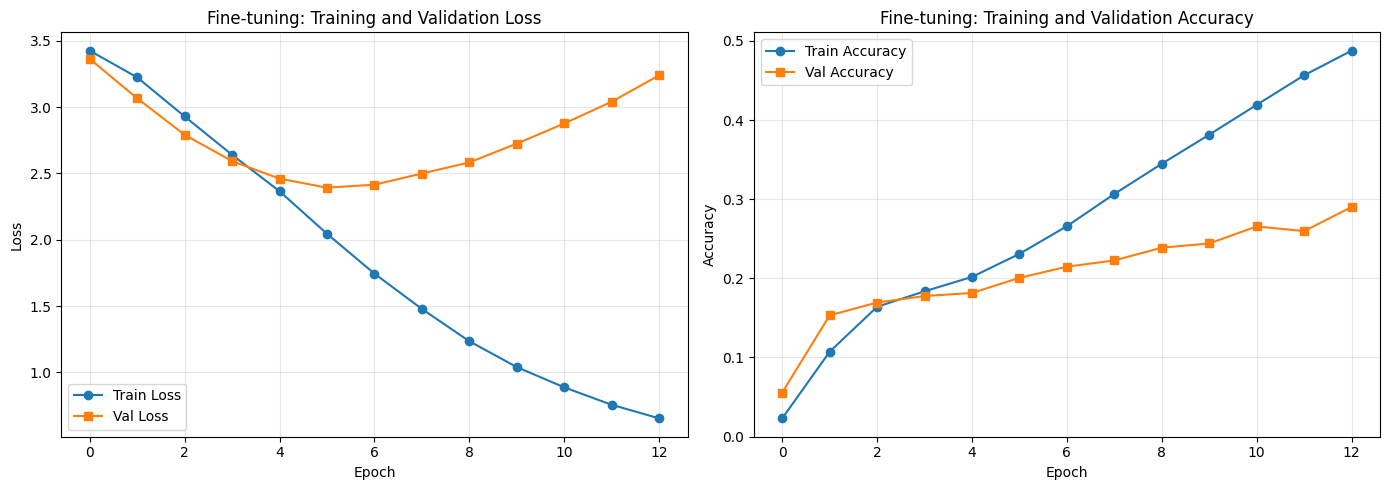

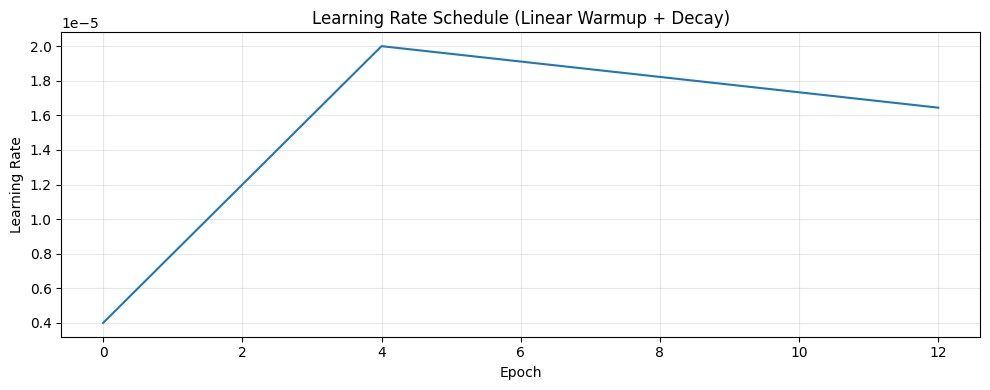


Per-class performance:
                    precision    recall  f1-score   support

           Cartman     0.5203    0.3320    0.4054      1503
              Stan     0.4066    0.1998    0.2680      1166
              Kyle     0.3837    0.2433    0.2978      1085
           Butters     0.3769    0.3113    0.3409       408
             Randy     0.2224    0.3075    0.2581       400
      Mr. Garrison     0.1530    0.3313    0.2093       163
              Chef     0.2087    0.3116    0.2500       138
             Kenny     0.9630    0.9701    0.9665       134
            Sharon     0.2427    0.4328    0.3110       134
             Jimmy     0.3419    0.3922    0.3653       102
            Gerald     0.1071    0.1818    0.1348        99
        Mr. Mackey     0.5281    0.4796    0.5027        98
             Liane     0.3763    0.3889    0.3825        90
             Wendy     0.1440    0.3933    0.2108        89
            Sheila     0.2231    0.3140    0.2609        86
             Ji

In [13]:
def evaluate_distilbert(model, loader):
    """Evaluate DistilBERT model on a dataset."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='macro', zero_division=0),
        'recall': recall_score(all_labels, all_preds, average='macro', zero_division=0),
        'f1_score': f1_score(all_labels, all_preds, average='macro', zero_division=0)
    }

    return metrics, all_preds, all_labels


# Evaluate on test set
test_metrics, test_preds, test_labels_list = evaluate_distilbert(model, test_loader)

# Print results
print("=" * 80)
print("DISTILBERT (PRE-TRAINED) - TEST SET PERFORMANCE")
print("=" * 80)
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1-Score:  {test_metrics['f1_score']:.4f}")
print("=" * 80)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(results['history']['train_loss'], label='Train Loss', marker='o')
axes[0].plot(results['history']['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Fine-tuning: Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(results['history']['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(results['history']['val_acc'], label='Val Accuracy', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Fine-tuning: Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'distilbert_k{K}_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot learning rate schedule
plt.figure(figsize=(10, 4))
plt.plot(results['history']['lr'])
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule (Linear Warmup + Decay)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'distilbert_k{K}_lr_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class performance
print("\nPer-class performance:")
from sklearn.metrics import classification_report
print(classification_report(
    test_labels_list,
    test_preds,
    target_names=[label_to_char[i] for i in range(K)],
    digits=4
))

In [ ]:
from sklearn.metrics import classification_report

# Generate classification report for per-class performance
print("\n" + "=" * 80)
print("PER-CLASS PERFORMANCE REPORT")
print("=" * 80)
report = classification_report(
    test_labels_list,
    test_preds,
    labels=np.arange(K),
    target_names=[label_to_char[i] for i in np.arange(K)],
    zero_division=0
)
print(report)
print("=" * 80)

## 13. Save Model\n\nSave the fine-tuned DistilBERT model with full configuration and metrics.

In [14]:
# Save checkpoint
checkpoint = {
    'model_type': 'DistilBERT (Fine-tuned)',
    'model_state_dict': model.state_dict(),
    'config': {
        'K': K,
        'model_name': MODEL_NAME,
        'max_seq_len': MAX_SEQ_LEN,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'warmup_ratio': WARMUP_RATIO,
        'num_epochs': NUM_EPOCHS,
        'early_stop_patience': EARLY_STOP_PATIENCE
    },
    'char_to_label': char_to_label,
    'label_to_char': label_to_char,
    'test_metrics': test_metrics,
    'history': results['history'],
    'training_time': results['time'],
    'total_parameters': sum(p.numel() for p in model.parameters())
}

# Save model checkpoint
filename = f'distilbert_k{K}.pt'
torch.save(checkpoint, filename)

# Also save the full model in Hugging Face format (optional)
model_dir = f'distilbert_south_park_k{K}'
model.save_pretrained(model_dir)
tokenizer.save_pretrained(model_dir)

print(f"Model saved to: {filename}")
print(f"Hugging Face model saved to: {model_dir}/")

print(f"\nModel Summary:")
print(f"  Architecture: DistilBERT (Fine-tuned)")
print(f"  Base model: {MODEL_NAME}")
print(f"  Parameters: {checkpoint['total_parameters']:,}")
print(f"  Max sequence length: {MAX_SEQ_LEN}")
print(f"  Vocabulary size: {len(tokenizer):,}")

print(f"\nPerformance:")
print(f"  Test Accuracy: {test_metrics['accuracy']:.4f}")
print(f"  Test Precision: {test_metrics['precision']:.4f}")
print(f"  Test Recall: {test_metrics['recall']:.4f}")
print(f"  Test F1-Score: {test_metrics['f1_score']:.4f}")
print(f"  Fine-tuning time: {results['time']/60:.2f} minutes")

print(f"\nComparison with other models:")
print(f"  Compare this fine-tuned DistilBERT with:")
print(f"    - baseline_logistic_regression.ipynb (~100K params)")
print(f"    - rnn_lstm_gru_models.ipynb (~200-400K params)")
print(f"    - seq2seq_basic.ipynb (~300-500K params)")
print(f"    - transformer_bert_model.ipynb (~1-2M params, custom)")
print(f"    - transformer_distilbert_model.ipynb (~66M params, pre-trained) <- YOU ARE HERE")

print(f"\nExpected performance ranking (highest to lowest):")
print(f"  1. DistilBERT (pre-trained) - Best language understanding")
print(f"  2. Custom BERT-style - Good architecture, trained from scratch")
print(f"  3. Seq2Seq with attention - Attention mechanism helps")
print(f"  4. LSTM/GRU - Better than simple RNN")
print(f"  5. RNN - Sequential processing")
print(f"  6. Baseline logistic regression - Simple bag-of-words")

print(f"\nTo load this model later:")
print(f"  # Load from checkpoint")
print(f"  checkpoint = torch.load('{filename}')")
print(f"  model.load_state_dict(checkpoint['model_state_dict'])")
print(f"  ")
print(f"  # Or load from Hugging Face format")
print(f"  model = DistilBertForSequenceClassification.from_pretrained('{model_dir}')")
print(f"  tokenizer = DistilBertTokenizer.from_pretrained('{model_dir}')")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: distilbert_k31.pt
Hugging Face model saved to: distilbert_south_park_k31/

Model Summary:
  Architecture: DistilBERT (Fine-tuned)
  Base model: distilbert-base-uncased
  Parameters: 66,977,311
  Max sequence length: 256
  Vocabulary size: 30,522

Performance:
  Test Accuracy: 0.3031
  Test Precision: 0.2615
  Test Recall: 0.3311
  Test F1-Score: 0.2789
  Fine-tuning time: 152.68 minutes

Comparison with other models:
  Compare this fine-tuned DistilBERT with:
    - baseline_logistic_regression.ipynb (~100K params)
    - rnn_lstm_gru_models.ipynb (~200-400K params)
    - seq2seq_basic.ipynb (~300-500K params)
    - transformer_bert_model.ipynb (~1-2M params, custom)
    - transformer_distilbert_model.ipynb (~66M params, pre-trained) <- YOU ARE HERE

Expected performance ranking (highest to lowest):
  1. DistilBERT (pre-trained) - Best language understanding
  2. Custom BERT-style - Good architecture, trained from scratch
  3. Seq2Seq with attention - Attention mechanism 